<a href="https://colab.research.google.com/github/JONG1510/6m-data-3.2-Probability-Statistics-for-Machine-Learning/blob/main/notebooks/02_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Distributions — Reading the Shape of Data
**⏱ This section takes approximately 60 minutes.**

---

## Scenario: Tuesday — Explaining "Skewed" to Priya

Sarah arrives Tuesday morning ready to address Priya's question from Friday.
Her plan: pull all 10,000 polarity scores and *show* Priya what the data actually looks like,
rather than summarising it as one number.

But as soon as she plots the histogram, she realises she has a new problem:
the data is not a nice bell curve. It leans. Priya is going to ask what that means.

> *"The chart shows more high scores on the right, with a longer tail on the left. What does that mean for the 60% figure?"*
> — Priya, after seeing the plot

**By the end of this notebook you will be able to:**
- Describe the shape of any distribution using the right vocabulary
- Explain why mean and median diverge in skewed data
- Calculate and interpret Z-scores to identify unusual values
- Recognise when distribution shape affects modelling decisions


In [13]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("✅ Libraries loaded — you're ready to go!")


✅ Libraries loaded — you're ready to go!


## Rebuilding Sarah's Dataset

We start from the same synthetic data as the pre-class hook notebook —
Sarah's 10,000 polarity scores from the L01 sentiment model run.


In [14]:
# Recreate the NorthStar polarity scores (same seed as 01_monday_morning.ipynb)
np.random.seed(42)
n_reviews = 10_000

# 60% positive, right-skewed: mildly-positive bulk + long positive tail,
# smaller negative cluster nearer zero
positive = np.random.exponential(scale=0.35, size=6_000)
positive = np.clip(positive, 0.001, 1.0)
negative = -np.random.exponential(scale=0.20, size=4_000)
negative = np.clip(negative, -1.0, -0.001)
polarity_scores = np.concatenate([positive, negative])
np.random.shuffle(polarity_scores)

# Also generate synthetic review lengths (word count per review)
review_lengths = np.random.exponential(scale=45, size=n_reviews).astype(int) + 5
review_lengths = np.clip(review_lengths, 5, 500)

reviews_df = pd.DataFrame({
    'polarity': polarity_scores,
    'word_count': review_lengths,
    'label': np.where(polarity_scores > 0, 'POSITIVE', 'NEGATIVE')
})

print(f"Dataset ready: {len(reviews_df):,} reviews")
print(reviews_df.describe().round(3))

Dataset ready: 10,000 reviews
        polarity  word_count
count  10000.000   10000.000
mean       0.121      49.680
std        0.356      45.108
min       -1.000       5.000
25%       -0.092      17.000
50%        0.062      36.000
75%        0.306      67.000
max        1.000     415.000


## 🎯 What is a Distribution?

**The idea in plain English:**
> A distribution is the pattern of how often each value appears in a dataset. It answers the question: "What does this data look like — where do values cluster, and how spread out are they?"

**The coffee shop analogy:** A coffee shop records its daily customer count for a year. Some days are quiet (50 customers), some are very busy (250), but most days fall somewhere in between. If you drew a bar chart of every day's count, the shape of that chart is the distribution. It tells you what a "typical" day looks like, and which days were unusual.

**Why it matters for ML:** Most ML algorithms behave differently depending on the shape of the data they receive. A linear model implicitly assumes roughly normal (bell-shaped) features. A gradient-boosted tree is more robust to shape, but still affected by extreme outliers. Knowing the distribution is step one of any data analysis.

---

### The three shapes you will see most often

| Shape | What it looks like | Real-world examples |
|---|---|---|
| **Normal (bell curve)** | Symmetric, peak in the middle, thin tails | Heights, test scores, measurement errors |
| **Right-skewed** | Peak on the left, long tail to the right | Incomes, house prices, review lengths |
| **Left-skewed** | Peak on the right, long tail to the left | Exam scores on an easy exam, age at retirement |


## ⏸️ Pause and Predict

We're about to plot two distributions side by side:
1. The polarity scores of NorthStar reviews
2. The word counts of those same reviews

**Before running the cell below, predict:**
- Which of the three shapes (normal / right-skewed / left-skewed) do you expect each distribution to have?
- For each distribution: will the mean be higher, lower, or roughly equal to the median?

*Write your prediction here (double-click this cell to edit):*


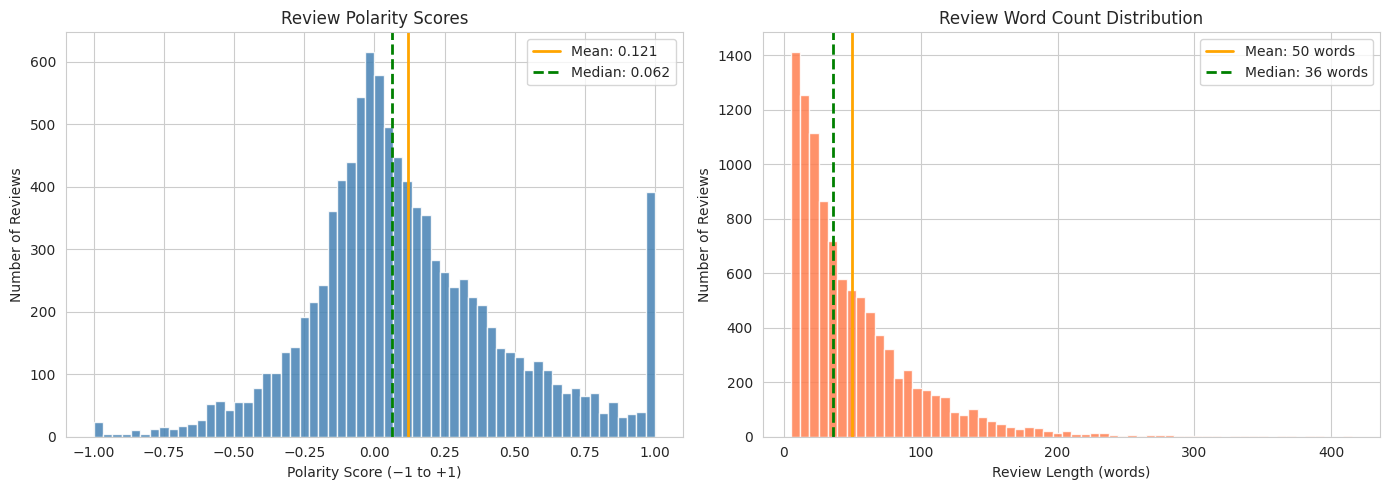

Polarity scores:
  Mean: 0.121  |  Median: 0.062
  Skew: 0.466  (positive = right-skewed; negative = left-skewed)

Review lengths:
  Mean: 49.7 words  |  Median: 36 words
  Skew: 1.993


In [15]:
# Plot the polarity and review-length distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: polarity scores ---
ax1 = axes[0]
ax1.hist(reviews_df['polarity'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(reviews_df['polarity'].mean(), color='orange', linewidth=2,
            label=f"Mean: {reviews_df['polarity'].mean():.3f}")
ax1.axvline(reviews_df['polarity'].median(), color='green', linewidth=2, linestyle='--',
            label=f"Median: {reviews_df['polarity'].median():.3f}")
ax1.set_xlabel("Polarity Score (−1 to +1)")
ax1.set_ylabel("Number of Reviews")
ax1.set_title("Review Polarity Scores")
ax1.legend()

# --- Right panel: review word counts ---
ax2 = axes[1]
ax2.hist(reviews_df['word_count'], bins=60, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(reviews_df['word_count'].mean(), color='orange', linewidth=2,
            label=f"Mean: {reviews_df['word_count'].mean():.0f} words")
ax2.axvline(reviews_df['word_count'].median(), color='green', linewidth=2, linestyle='--',
            label=f"Median: {reviews_df['word_count'].median():.0f} words")
ax2.set_xlabel("Review Length (words)")
ax2.set_ylabel("Number of Reviews")
ax2.set_title("Review Word Count Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

print("Polarity scores:")
print(f"  Mean: {reviews_df['polarity'].mean():.3f}  |  Median: {reviews_df['polarity'].median():.3f}")
print(f"  Skew: {reviews_df['polarity'].skew():.3f}  (positive = right-skewed; negative = left-skewed)")
print()
print("Review lengths:")
print(f"  Mean: {reviews_df['word_count'].mean():.1f} words  |  Median: {reviews_df['word_count'].median():.0f} words")
print(f"  Skew: {reviews_df['word_count'].skew():.3f}")


### 💡 What do you notice?

- **Polarity scores are right-skewed** — there is a long tail to the right (very positive reviews) and most reviews cluster in the mildly-positive range. The mean is pulled upward by those extreme positive values.
- **Review lengths are strongly right-skewed** — most reviews are short (under 60 words), but a long tail of very long reviews stretches to the right. The mean length is noticeably higher than the median because those long reviews pull the average up.
- **Mean vs median** — the gap tells you about the skew. Where the mean is *above* the median, the data is right-skewed. Where the mean is *below* the median, the data is left-skewed.

**Back to our scenario:**
> If Priya asks "how long is a typical review?", the median (around 40 words) is more honest than the mean (pulled higher by a few very long complaints). This is exactly the kind of nuance that separates a useful data analyst from one who just runs code.

## ✅ Section Summary

| Concept | What it means | Real-world use |
|---|---|---|
| **Distribution** | The pattern of how often each value appears in a dataset | Understanding what "normal" looks like before flagging anomalies |
| **Normal (bell curve)** | Symmetric, mean ≈ median, thin tails | Heights, test scores, measurement errors |
| **Right-skewed** | Long tail to the right, mean > median | Incomes, review lengths, house prices |
| **Left-skewed** | Long tail to the left, mean < median | Easy exam scores, age at retirement |
| **Mean vs Median** | Mean is sensitive to extremes; median is resistant | Always check both when the distribution might be skewed |

**Key insight for our scenario:**
> Sarah's polarity scores are mildly right-skewed — the median is the more representative summary for Priya. *Knowing the shape of the data is step one of any serious ML project.*

---
**Up next → Part 2:** Wednesday — Sarah labels 200 reviews by hand and learns to put a confidence bracket around her 84% accuracy.
Open `03_confidence_intervals.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

This optional section covers:
- **Z-scores** — how to flag unusual values (a key feature-standardisation technique used in ML)
- **Normal vs Skewed contrast** — a side-by-side comparison using heights and household incomes

## 🎯 Z-scores: Measuring How Unusual a Value Is

**The idea in plain English:**
> A Z-score answers: *"How many standard deviations away from the average is this value?"*
> Z = 0 means exactly average. Z = 2 means "two standard deviations above average." Z = −3 means "very far below average."

**Formula:**
```
z = (value − mean) / standard deviation
```

**The exam score analogy:** You score 85 on an exam. Is that good?
- If the class average was 60 and the standard deviation was 10 → Z = (85−60)/10 = **2.5** — top 1% of the class.
- If the class average was 82 and the standard deviation was 2 → Z = (85−82)/2 = **1.5** — above average, but not exceptional.
The raw score means nothing without context; the Z-score provides that context instantly.

**Why it matters for ML:**
Z-scores are the foundation of *feature standardisation* — one of the most common preprocessing steps before training a model. They are also how anomaly detection works: any value with |Z| > 3 is worth investigating as a potential outlier.


In [16]:
# Compute Z-scores for the polarity scores
pol_mean = polarity_scores.mean()
pol_std  = polarity_scores.std()

reviews_df['z_score'] = (reviews_df['polarity'] - pol_mean) / pol_std

# Show some examples
print(f"Population mean: {pol_mean:.4f}")
print(f"Population std:  {pol_std:.4f}")
print()
print("Example Z-scores:")
examples = reviews_df.nlargest(3, 'z_score')[['polarity','z_score','label']].round(3)
examples2 = reviews_df.nsmallest(3, 'z_score')[['polarity','z_score','label']].round(3)
print("  Most positive reviews:")
print(examples.to_string(index=False))
print()
print("  Most negative reviews:")
print(examples2.to_string(index=False))


Population mean: 0.1206
Population std:  0.3564

Example Z-scores:
  Most positive reviews:
 polarity  z_score    label
      1.0    2.467 POSITIVE
      1.0    2.467 POSITIVE
      1.0    2.467 POSITIVE

  Most negative reviews:
 polarity  z_score    label
     -1.0   -3.144 NEGATIVE
     -1.0   -3.144 NEGATIVE
     -1.0   -3.144 NEGATIVE


Reviews with |Z| > 3.0: 27 (0.27%)
  ...of which 0 are unusually POSITIVE (Z > +3)
  ...and       27 are unusually NEGATIVE (Z < -3)



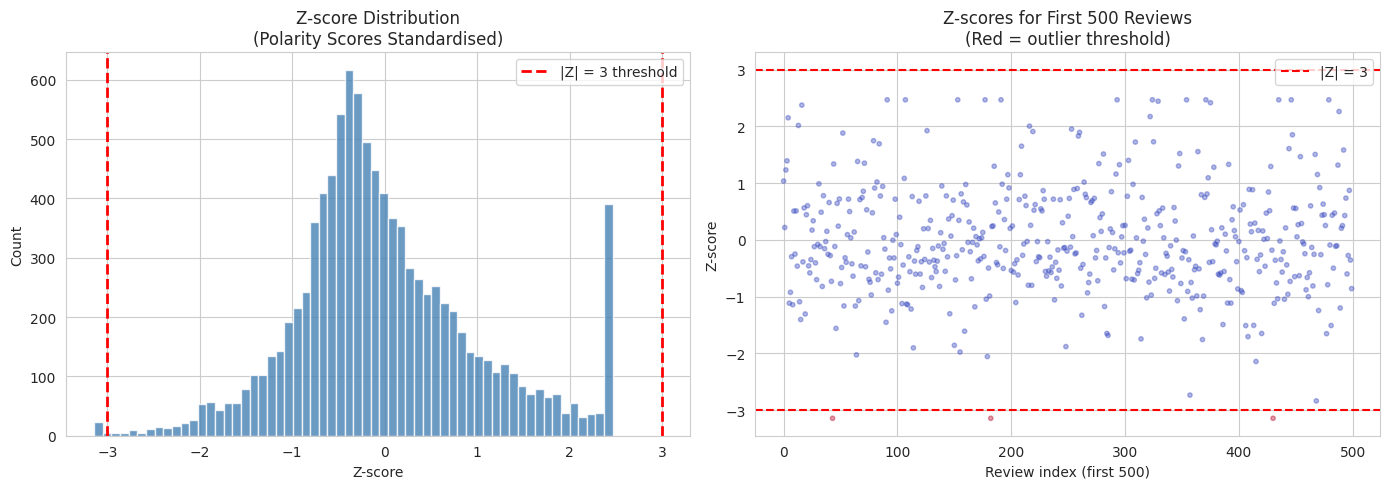

Interpretation:
  Z >  3 (if any): unusually POSITIVE — possible sycophancy or bot review
  Z < -3:          unusually NEGATIVE — flag for immediate customer service response

  Right-skewed sentiment data tends to produce more extreme negatives than positives,
  because the long positive tail spreads its mass thinly while negatives cluster tighter.


In [17]:
# Identify outliers using Z-score threshold
outlier_threshold = 3.0
outliers = reviews_df[np.abs(reviews_df['z_score']) > outlier_threshold]
n_pos_outliers = (reviews_df['z_score'] >  outlier_threshold).sum()
n_neg_outliers = (reviews_df['z_score'] < -outlier_threshold).sum()

print(f"Reviews with |Z| > {outlier_threshold}: {len(outliers)} ({len(outliers)/len(reviews_df):.2%})")
print(f"  ...of which {n_pos_outliers} are unusually POSITIVE (Z > +3)")
print(f"  ...and       {n_neg_outliers} are unusually NEGATIVE (Z < -3)")
print()

# Visualise Z-score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(reviews_df['z_score'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(-3, color='red', linewidth=2, linestyle='--', label='|Z| = 3 threshold')
ax1.axvline(3, color='red', linewidth=2, linestyle='--')
ax1.set_xlabel("Z-score")
ax1.set_ylabel("Count")
ax1.set_title("Z-score Distribution\n(Polarity Scores Standardised)")
ax1.legend()

ax2 = axes[1]
ax2.scatter(reviews_df.index[:500], reviews_df['z_score'][:500],
            c=np.abs(reviews_df['z_score'][:500]) > 3,
            cmap='coolwarm', alpha=0.4, s=10)
ax2.axhline(3, color='red', linewidth=1.5, linestyle='--', label='|Z| = 3')
ax2.axhline(-3, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlabel("Review index (first 500)")
ax2.set_ylabel("Z-score")
ax2.set_title("Z-scores for First 500 Reviews\n(Red = outlier threshold)")
ax2.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"  Z >  3 (if any): unusually POSITIVE — possible sycophancy or bot review")
print(f"  Z < -3:          unusually NEGATIVE — flag for immediate customer service response")
print()
print(f"  Right-skewed sentiment data tends to produce more extreme negatives than positives,")
print(f"  because the long positive tail spreads its mass thinly while negatives cluster tighter.")

### 💡 What do you notice?

- **Very few reviews fall outside the ±3 threshold** — consistent with what you'd expect from a roughly bell-shaped distribution. About 0.3% of values fall beyond Z = ±3 by chance in a perfectly normal distribution, and our right-skewed data lands close to that figure.
- **The outliers are all on the negative side** — there's no Z above +3, but a handful of reviews sit below −3. That asymmetry is the right-skew showing up in the standardised view: the long positive tail spreads its mass too thinly to produce extreme Z-scores, while negatives cluster tighter and produce a few genuine outliers.
- **Z-scores standardise** the data — the distribution is centred around 0 and measured in "standard deviation" units regardless of the original scale. You can compare Z-scores across completely different variables.
- **Outliers are automatic flags** — a review with Z = −3.1 is a genuine extreme negative, worth routing to customer service immediately.

**Back to our scenario:**
> Sarah can tell Priya: *"I've flagged about 30 reviews with Z-scores below −3 — these are the most extreme complaints. I've routed them to Aisha's team."* This is more actionable than just saying "40% are negative."

## 🎯 Normal vs Skewed — A Concrete Comparison

Let's see the contrast more clearly by generating two synthetic datasets that
represent classic real-world distributions.

We will use:
- **Heights** of 1,000 adults — a textbook normal distribution
- **Monthly household incomes** — a textbook right-skewed distribution

These are separate from Sarah's review data, but we will use the same scenario
vocabulary to explain what we see.


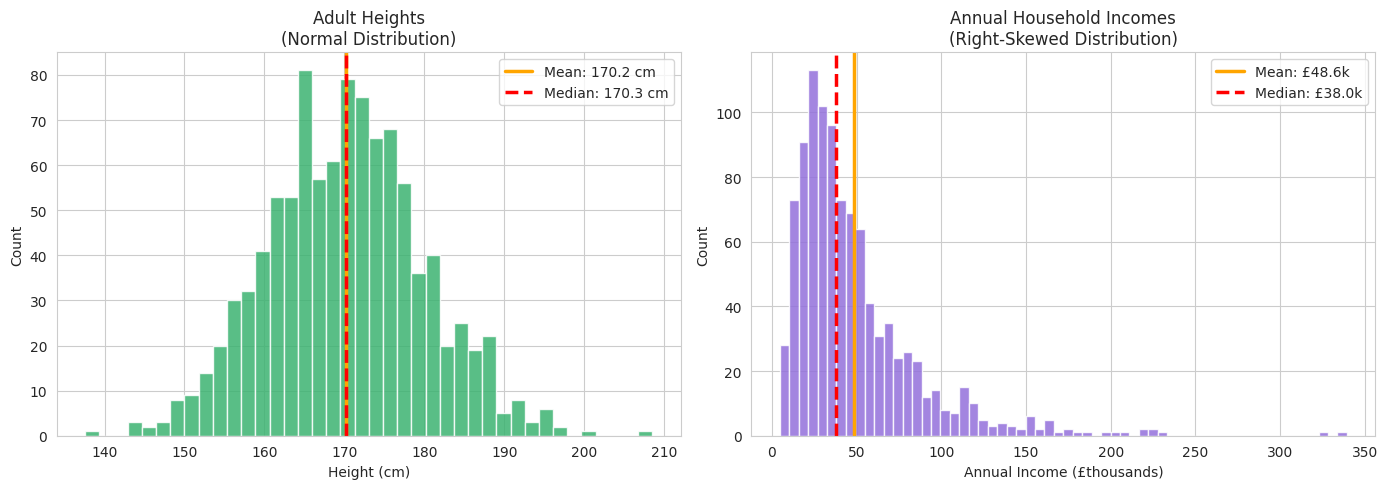

Heights — Mean vs Median gap: -0.06 cm
Incomes — Mean vs Median gap: £ 10.6 k

In the income data, the mean is HIGHER than the median — a few high earners pull the mean up.
When a politician quotes 'average household income', always ask: mean or median?


In [18]:
# Generate the two contrast datasets
np.random.seed(42)

# Heights: normally distributed around 170cm, std = 10cm
heights = np.random.normal(loc=170, scale=10, size=1000)

# Incomes: right-skewed (log-normal) — most earn moderate amounts,
# a small tail earns very high incomes
incomes = np.random.lognormal(mean=10.5, sigma=0.7, size=1000)  # in £
incomes_k = incomes / 1000  # rescale to £ thousands for easier reading

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heights
ax1 = axes[0]
ax1.hist(heights, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax1.axvline(heights.mean(), color='orange', linewidth=2.5, label=f"Mean: {heights.mean():.1f} cm")
ax1.axvline(np.median(heights), color='red', linewidth=2.5, linestyle='--',
            label=f"Median: {np.median(heights):.1f} cm")
ax1.set_xlabel("Height (cm)")
ax1.set_ylabel("Count")
ax1.set_title("Adult Heights\n(Normal Distribution)")
ax1.legend()

# Incomes
ax2 = axes[1]
ax2.hist(incomes_k, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
ax2.axvline(incomes_k.mean(), color='orange', linewidth=2.5,
            label=f"Mean: £{incomes_k.mean():.1f}k")
ax2.axvline(np.median(incomes_k), color='red', linewidth=2.5, linestyle='--',
            label=f"Median: £{np.median(incomes_k):.1f}k")
ax2.set_xlabel("Annual Income (£thousands)")
ax2.set_ylabel("Count")
ax2.set_title("Annual Household Incomes\n(Right-Skewed Distribution)")
ax2.legend()

plt.tight_layout()
plt.show()

print("Heights — Mean vs Median gap:", round(heights.mean() - np.median(heights), 2), "cm")
print("Incomes — Mean vs Median gap: £", round(incomes_k.mean() - np.median(incomes_k), 1), "k")
print()
print("In the income data, the mean is HIGHER than the median — a few high earners pull the mean up.")
print("When a politician quotes 'average household income', always ask: mean or median?")

### 💡 What do you notice?

- **Heights:** the mean and median are almost identical. The distribution is symmetric. This is the hallmark of a normal distribution.
- **Incomes:** the mean is noticeably higher than the median. A small number of very high earners in the right tail pull the average up. The median is more representative of what a "typical" household actually earns.
- **The shape controls which summary you should report.** For symmetric data, mean and median are interchangeable. For skewed data, the median is almost always more honest as a "typical" value.

**Back to our scenario:**
> Sarah's polarity scores are slightly right-skewed. She should show Priya the distribution, not just the mean, and report the median polarity as the more representative summary. This is a small but important distinction that builds Priya's trust in Sarah's analysis.
